# Geometry-based data selection on cleaned WikiText

Этот ноутбук:

1. агрессивно чистит WikiText от явных и неявных заголовков и других шумных строк
2. считает baseline по perplexity и geometry score на очищенных кусках текста
3. обучает маленький language model и строит scaling curves для 10%, 30%, 70% и 100%
4. сразу пишет все артефакты в Google Drive и сохраняет метрики после каждой эпохи

Перед запуском:
- в Colab выбери GPU runtime
- запусти ноутбук сверху вниз
- не меняй `cfg.out_dir`, если хочешь чтобы результаты пережили перезапуск runtime


In [ ]:
%%capture
!pip -q install -U datasets transformers tokenizers sentencepiece scikit-learn tqdm

In [ ]:
import os
import re
import gc
import math
import json
import time
import random
import pickle
import hashlib
from pathlib import Path
from dataclasses import dataclass, asdict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.neighbors import NearestNeighbors

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

from transformers import (
    PreTrainedTokenizerFast,
    AutoTokenizer,
    AutoModel,
    AutoModelForCausalLM,
    get_cosine_schedule_with_warmup,
)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True

device = "cuda" if torch.cuda.is_available() else "cpu"
amp_enabled = device == "cuda"
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: Tesla T4


In [ ]:
USE_GOOGLE_DRIVE = True
REQUIRE_GPU = True
DRIVE_FOLDER_NAME = "geom_distill_outputs"

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if USE_GOOGLE_DRIVE and IN_COLAB:
    drive.mount("/content/drive", force_remount=False)
    BASE_OUT_DIR = Path("/content/drive/MyDrive") / DRIVE_FOLDER_NAME
else:
    BASE_OUT_DIR = Path(DRIVE_FOLDER_NAME)

BASE_OUT_DIR.mkdir(parents=True, exist_ok=True)
print("BASE_OUT_DIR =", BASE_OUT_DIR)

if REQUIRE_GPU and device != "cuda":
    raise RuntimeError(
        "GPU runtime is not enabled. In Colab choose Runtime -> Change runtime type -> GPU and rerun from the top."
    )
elif device != "cuda":
    print("warning: running on CPU will be much slower")

Mounted at /content/drive
BASE_OUT_DIR = /content/drive/MyDrive/geom_distill_outputs


In [ ]:
@dataclass
class CFG:
    dataset_name: str = "wikitext"
    dataset_config: str = "wikitext-103-raw-v1"
    use_streaming: bool = True

    max_train_chunks: int | None = 6000
    max_val_chunks: int | None = 1200
    stream_progress_every: int = 100000

    vocab_size: int = 8192
    block_size: int = 128
    stride: int = 64

    batch_size: int = 48
    eval_batch_size: int = 64
    num_workers: int = 0

    d_model: int = 320
    nhead: int = 5
    num_layers: int = 5
    dim_feedforward: int = 1280
    dropout: float = 0.1

    lr: float = 3e-4
    weight_decay: float = 0.01
    max_epochs: int = 30
    warmup_ratio: float = 0.06
    early_stopping_patience: int = 5
    grad_clip: float = 1.0

    ref_ppl_model_name: str = "distilgpt2"
    embed_model_name: str = "sentence-transformers/all-MiniLM-L6-v2"
    score_batch_size: int = 16
    score_max_length: int = 192
    geometry_k: int = 16

    fractions: tuple = (0.10, 0.30, 0.70)

    out_dir: str = str(BASE_OUT_DIR)
    force_recompute_scores: bool = False
    force_retrain: bool = False

cfg = CFG()
out_dir = Path(cfg.out_dir)
cache_dir = out_dir / "cache"
exp_dir = out_dir / "experiments"
cache_dir.mkdir(parents=True, exist_ok=True)
exp_dir.mkdir(parents=True, exist_ok=True)

with open(out_dir / "cfg.json", "w", encoding="utf-8") as f:
    json.dump(asdict(cfg), f, ensure_ascii=False, indent=2)

print(asdict(cfg))
print("artifacts will be saved under:", out_dir)

{'dataset_name': 'wikitext', 'dataset_config': 'wikitext-103-raw-v1', 'use_streaming': True, 'max_train_chunks': 6000, 'max_val_chunks': 1200, 'stream_progress_every': 100000, 'vocab_size': 8192, 'block_size': 128, 'stride': 64, 'batch_size': 48, 'eval_batch_size': 64, 'num_workers': 0, 'd_model': 320, 'nhead': 5, 'num_layers': 5, 'dim_feedforward': 1280, 'dropout': 0.1, 'lr': 0.0003, 'weight_decay': 0.01, 'max_epochs': 30, 'warmup_ratio': 0.06, 'early_stopping_patience': 5, 'grad_clip': 1.0, 'ref_ppl_model_name': 'distilgpt2', 'embed_model_name': 'sentence-transformers/all-MiniLM-L6-v2', 'score_batch_size': 16, 'score_max_length': 192, 'geometry_k': 16, 'fractions': (0.1, 0.3, 0.7), 'out_dir': '/content/drive/MyDrive/geom_distill_outputs', 'force_recompute_scores': False, 'force_retrain': False}
artifacts will be saved under: /content/drive/MyDrive/geom_distill_outputs


In [ ]:
WIKI_REPLACEMENTS = [
    (" @-@ ", "-"),
    (" @,@ ", ","),
    (" @.@ ", "."),
    (" n't", "n't"),
    (" 's", "'s"),
    (" 'm", "'m"),
    (" 're", "'re"),
    (" 've", "'ve"),
    (" 'd", "'d"),
    (" 'll", "'ll"),
]

NOISY_PREFIXES = (
    "category:",
    "file:",
    "image:",
    "thumb|",
    "references",
    "external links",
    "see also",
)

def normalize_wikitext_line(text: str) -> str:
    text = text.replace("` `", '"').replace("''", '"')
    for old, new in WIKI_REPLACEMENTS:
        text = text.replace(old, new)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"\s+([,.;:!?])", r"\1", text)
    text = re.sub(r"\(\s+", "(", text)
    text = re.sub(r"\s+\)", ")", text)
    return text.strip()

def alpha_ratio(text: str) -> float:
    if not text:
        return 0.0
    chars = [c for c in text if not c.isspace()]
    if not chars:
        return 0.0
    alpha = sum(c.isalpha() for c in chars)
    return alpha / len(chars)

def digit_ratio(text: str) -> float:
    if not text:
        return 0.0
    chars = [c for c in text if not c.isspace()]
    if not chars:
        return 0.0
    digits = sum(c.isdigit() for c in chars)
    return digits / len(chars)

def weird_symbol_ratio(text: str) -> float:
    if not text:
        return 1.0
    chars = [c for c in text if not c.isspace()]
    if not chars:
        return 1.0
    bad = 0
    for c in chars:
        if c.isalnum():
            continue
        if c in ".,;:!?()'\"-":
            continue
        bad += 1
    return bad / len(chars)

def line_has_enough_vowels(text: str) -> bool:
    letters = re.findall(r"[A-Za-z]", text)
    if len(letters) < 25:
        return False
    vowels = sum(c.lower() in "aeiouy" for c in letters)
    return (vowels / len(letters)) >= 0.18

def is_explicit_heading(raw_line: str) -> bool:
    s = raw_line.strip()
    return bool(re.fullmatch(r"=+\s*[^=].*?[^=]?\s*=+", s))

def is_probable_implicit_heading(line: str, prev_blank: bool, next_blank: bool) -> bool:
    s = line.strip()
    if not s or len(s) > 90:
        return False
    if s.endswith((".", "!", "?", ";", ",")):
        return False
    words = re.findall(r"[A-Za-z][A-Za-z'’\-]*", s)
    if not (2 <= len(words) <= 12):
        return False

    title_like = 0
    for w in words:
        if w[0].isupper() and (len(w) == 1 or w[1:].islower()):
            title_like += 1
    title_ratio = title_like / len(words)

    all_caps_letters = [c for c in s if c.isalpha()]
    upper_ratio = 0.0 if not all_caps_letters else sum(c.isupper() for c in all_caps_letters) / len(all_caps_letters)

    surrounded = prev_blank or next_blank
    return surrounded and (title_ratio >= 0.75 or upper_ratio >= 0.8)

def is_noisy_line(line: str) -> bool:
    s = line.strip()
    if not s:
        return True
    low = s.lower()

    if low.startswith(NOISY_PREFIXES):
        return True
    if s.startswith(("*", "|", "!", "{", "}", "[[", "]]", "#", ";", ":")):
        return True
    if any(tag in s for tag in ["<ref", "</ref>", "{{", "}}", "[[", "]]", "thumb|"]):
        return True
    if re.search(r"\.(jpg|jpeg|png|svg|gif)\b", low):
        return True
    if "http://" in low or "https://" in low:
        return True
    if len(re.findall(r"[A-Za-z]", s)) < 20:
        return True
    if alpha_ratio(s) < 0.58:
        return True
    if digit_ratio(s) > 0.22:
        return True
    if weird_symbol_ratio(s) > 0.12:
        return True
    if not line_has_enough_vowels(s):
        return True
    if s.count("|") >= 2:
        return True
    return False

def split_into_sentences(text: str) -> list[str]:
    parts = re.split(r"(?<=[.!?])\s+", text)
    return [p.strip() for p in parts if p.strip()]

def chunk_document(text: str, target_words: int = 110, min_words: int = 55, max_words: int = 150) -> list[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []
    chunks = []
    cur = []
    cur_words = 0

    def flush():
        nonlocal cur, cur_words
        if cur:
            chunk = " ".join(cur).strip()
            n_words = len(chunk.split())
            if min_words <= n_words <= max_words and len(chunk) >= 250:
                chunks.append(chunk)
        cur = []
        cur_words = 0

    for sent in sentences:
        sent_words = len(sent.split())
        if sent_words > max_words:
            words = sent.split()
            for i in range(0, len(words), target_words):
                sub = " ".join(words[i:i + target_words]).strip()
                if min_words <= len(sub.split()) <= max_words and len(sub) >= 250:
                    flush()
                    chunks.append(sub)
            continue

        if cur_words + sent_words > max_words:
            flush()

        cur.append(sent)
        cur_words += sent_words

        if cur_words >= target_words:
            flush()

    flush()
    return chunks

def text_key(text: str) -> int:
    norm = re.sub(r"\W+", " ", text.lower()).strip()
    return int.from_bytes(hashlib.blake2b(norm.encode("utf-8"), digest_size=8).digest(), "big")

def reservoir_add(item, reservoir, seen_count, limit, rnd):
    if limit is None:
        reservoir.append(item)
        return
    if len(reservoir) < limit:
        reservoir.append(item)
        return
    j = rnd.randint(0, seen_count - 1)
    if j < limit:
        reservoir[j] = item

def clean_and_chunk_stream(split_iter, split_name: str, limit_chunks: int | None = None, progress_every: int = 100000):
    docs_seen = 0
    raw_lines_seen = 0
    removed_explicit = 0
    removed_implicit = 0
    removed_noisy = 0
    chunk_candidates_seen = 0
    implicit_heading_examples = []

    current = []
    prev_raw = ""
    prev_blank = True

    dedup_keys = set()
    sampled_chunks = []
    rnd = random.Random(seed)

    def flush_doc():
        nonlocal current, docs_seen, chunk_candidates_seen
        if current:
            doc = normalize_wikitext_line(" ".join(current))
            doc = re.sub(r"\s+", " ", doc).strip()
            if len(doc.split()) >= 70 and len(doc) >= 300:
                docs_seen += 1
                for chunk in chunk_document(doc):
                    key = text_key(chunk)
                    if key in dedup_keys:
                        continue
                    dedup_keys.add(key)
                    chunk_candidates_seen += 1
                    reservoir_add(chunk, sampled_chunks, chunk_candidates_seen, limit_chunks, rnd)
        current = []

    def process_line(raw_line: str, next_raw: str):
        nonlocal raw_lines_seen, prev_blank, removed_explicit, removed_implicit, removed_noisy
        raw_lines_seen += 1
        prev_blank_local = prev_blank
        next_blank = not next_raw.strip()
        line = normalize_wikitext_line(raw_line)

        if not line:
            flush_doc()
            prev_blank = True
            return

        if is_explicit_heading(raw_line):
            removed_explicit += 1
            flush_doc()
            prev_blank = True
            return

        if is_probable_implicit_heading(line, prev_blank_local, next_blank):
            removed_implicit += 1
            if len(implicit_heading_examples) < 12:
                implicit_heading_examples.append(line)
            flush_doc()
            prev_blank = True
            return

        if is_noisy_line(line):
            removed_noisy += 1
            prev_blank = False
            return

        current.append(line)
        prev_blank = False

        if progress_every and raw_lines_seen % progress_every == 0:
            print(
                f"[{split_name}] lines={raw_lines_seen:,} docs={docs_seen:,} "
                f"unique_chunks={chunk_candidates_seen:,} kept={len(sampled_chunks):,}"
            )

    it = iter(split_iter)
    try:
        prev_raw = next(it)["text"]
    except StopIteration:
        prev_raw = None

    if prev_raw is not None:
        for row in it:
            cur_raw = prev_raw
            next_raw = row["text"]
            process_line(cur_raw, next_raw)
            prev_raw = next_raw
        process_line(prev_raw, "")
    flush_doc()

    rnd.shuffle(sampled_chunks)

    stats = {
        "split": split_name,
        "raw_lines": raw_lines_seen,
        "docs_after_cleaning": docs_seen,
        "chunks_after_chunking": chunk_candidates_seen,
        "chunks_after_dedup_and_cap": len(sampled_chunks),
        "removed_explicit_headings": removed_explicit,
        "removed_implicit_headings": removed_implicit,
        "removed_noisy_lines": removed_noisy,
        "implicit_heading_examples": implicit_heading_examples,
    }
    return sampled_chunks, stats

def clean_and_chunk_split_materialized(split, split_name: str, limit_chunks: int | None = None):
    raw_lines = split["text"]
    docs = []
    removed_explicit = []
    removed_implicit = []
    removed_noisy = []

    current = []

    def flush_doc():
        nonlocal current
        if current:
            doc = normalize_wikitext_line(" ".join(current))
            doc = re.sub(r"\s+", " ", doc).strip()
            if len(doc.split()) >= 70 and len(doc) >= 300:
                docs.append(doc)
        current = []

    for i, raw_line in enumerate(raw_lines):
        prev_blank = i == 0 or (not raw_lines[i - 1].strip())
        next_blank = i == len(raw_lines) - 1 or (not raw_lines[i + 1].strip())
        line = normalize_wikitext_line(raw_line)

        if not line:
            flush_doc()
            continue

        if is_explicit_heading(raw_line):
            removed_explicit.append(raw_line)
            flush_doc()
            continue

        if is_probable_implicit_heading(line, prev_blank, next_blank):
            removed_implicit.append(line)
            flush_doc()
            continue

        if is_noisy_line(line):
            removed_noisy.append(line)
            continue

        current.append(line)

    flush_doc()

    chunks = []
    for doc in docs:
        chunks.extend(chunk_document(doc))

    dedup = []
    seen = set()
    for chunk in chunks:
        key = text_key(chunk)
        if key not in seen:
            seen.add(key)
            dedup.append(chunk)

    rnd = random.Random(seed)
    rnd.shuffle(dedup)
    if limit_chunks is not None:
        dedup = dedup[:limit_chunks]

    stats = {
        "split": split_name,
        "raw_lines": len(raw_lines),
        "docs_after_cleaning": len(docs),
        "chunks_after_chunking": len(chunks),
        "chunks_after_dedup_and_cap": len(dedup),
        "removed_explicit_headings": len(removed_explicit),
        "removed_implicit_headings": len(removed_implicit),
        "removed_noisy_lines": len(removed_noisy),
        "implicit_heading_examples": removed_implicit[:12],
    }
    return dedup, stats

def load_and_prepare_split(split_name: str, limit_chunks: int | None):
    if cfg.use_streaming:
        split_iter = load_dataset(
            cfg.dataset_name,
            cfg.dataset_config,
            split=split_name,
            streaming=True,
        )
        return clean_and_chunk_stream(
            split_iter,
            split_name=split_name,
            limit_chunks=limit_chunks,
            progress_every=cfg.stream_progress_every,
        )
    split = load_dataset(cfg.dataset_name, cfg.dataset_config, split=split_name)
    return clean_and_chunk_split_materialized(split, split_name, limit_chunks)

train_texts, train_stats = load_and_prepare_split("train", cfg.max_train_chunks)
val_texts, val_stats = load_and_prepare_split("validation", cfg.max_val_chunks)

stats_df = pd.DataFrame([train_stats, val_stats])
display(stats_df)

print("sample cleaned train chunk:")
print(train_texts[0][:1200])
print()
print("examples of removed implicit headings:")
for x in train_stats["implicit_heading_examples"][:10]:
    print("-", x)


with open(out_dir / "data_stats.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "train_stats": train_stats,
            "val_stats": val_stats,
            "n_train_texts": len(train_texts),
            "n_val_texts": len(val_texts),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )
stats_df.to_csv(out_dir / "data_stats.csv", index=False)
print("saved data stats to", out_dir / "data_stats.json")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

[train] lines=100,000 docs=13,475 unique_chunks=38,687 kept=6,000
[train] lines=200,000 docs=27,079 unique_chunks=77,955 kept=6,000
[train] lines=300,000 docs=40,501 unique_chunks=116,992 kept=6,000
[train] lines=600,000 docs=80,798 unique_chunks=234,779 kept=6,000
[train] lines=700,000 docs=94,389 unique_chunks=273,595 kept=6,000
[train] lines=900,000 docs=121,579 unique_chunks=352,454 kept=6,000
[train] lines=1,100,000 docs=148,554 unique_chunks=429,796 kept=6,000
[train] lines=1,200,000 docs=162,090 unique_chunks=469,478 kept=6,000
[train] lines=1,500,000 docs=202,456 unique_chunks=585,465 kept=6,000
[train] lines=1,700,000 docs=229,248 unique_chunks=662,594 kept=6,000


,split,raw_lines,docs_after_cleaning,chunks_after_chunking,chunks_after_dedup_and_cap,removed_explicit_headings,removed_implicit_headings,removed_noisy_lines,implicit_heading_examples
0,train,1801350,242895,701089,6000,305074,8318,48653,"[Beautiful Bible Pictures; Blackie, 1932, Retu..."
1,validation,3760,484,1514,1200,620,8,85,"[Interstate Highways, Pet Shop Boys – Keyboard..."


sample cleaned train chunk:
The inadequacy of the police's firepower led to criticism in the press, and on 12 January 1911 several alternative weapons were tested. The trials resulted in the decision by the Metropolitan Police to replace the Webley revolver with the Webley & Scott.32 calibre MP semi-automatic pistol later that year; the City of London Police followed suit with the same choice in 1912. The members of the group dispersed after the events. Peter the Painter was never seen or heard from again. It was assumed he left the country, and there were several possible sightings in the years afterwards, although none were confirmed. Jacob Peters returned to Russia, rose to be deputy head of the Cheka, the Soviet secret police, and was executed in Joseph Stalin's 1938 purge.

examples of removed implicit headings:
- Beautiful Bible Pictures; Blackie, 1932
- Return to Fairyopolis; Frederick Warne, 2008
- St. Cecily's Garden; 1920
- Note: Pos
- Assists; Pts
- Time On Ice (minutes); W


In [ ]:
tokenizer_backend = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer_backend.pre_tokenizer = ByteLevel(add_prefix_space=False)
tokenizer_backend.decoder = ByteLevelDecoder()
trainer = BpeTrainer(
    vocab_size=cfg.vocab_size,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"],
    show_progress=True,
)
tokenizer_backend.train_from_iterator(train_texts, trainer=trainer)

tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer_backend,
    pad_token="[PAD]",
    unk_token="[UNK]",
    bos_token="[BOS]",
    eos_token="[EOS]",
)

print(tokenizer.vocab_size)
print(tokenizer("The history of artificial intelligence")["input_ids"][:20])

tokenizer.save_pretrained(str(out_dir / "tokenizer"))
print("saved tokenizer to", out_dir / "tokenizer")


8192
[506, 1700, 218, 8169, 392, 7787]
saved tokenizer to /content/drive/MyDrive/geom_distill_outputs/tokenizer


In [ ]:
class CausalLMDataset(Dataset):
    def __init__(self, texts, tokenizer, block_size: int, stride: int):
        self.block_size = block_size
        token_ids = []
        eos = tokenizer.eos_token_id

        for text in texts:
            ids = tokenizer.encode(text, add_special_tokens=False)
            if len(ids) < 8:
                continue
            token_ids.extend(ids + [eos])

        self.tokens = torch.tensor(token_ids, dtype=torch.long)
        self.starts = list(range(0, len(self.tokens) - block_size - 1, stride))

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        s = self.starts[idx]
        seq = self.tokens[s:s + self.block_size + 1]
        x = seq[:-1]
        y = seq[1:]
        return x, y

def make_loaders(train_subset_texts, val_texts, tokenizer, cfg):
    train_ds = CausalLMDataset(train_subset_texts, tokenizer, cfg.block_size, cfg.stride)
    val_ds = CausalLMDataset(val_texts, tokenizer, cfg.block_size, cfg.block_size)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=(device == "cuda"),
        persistent_workers=(cfg.num_workers > 0),
        drop_last=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.eval_batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=(device == "cuda"),
        persistent_workers=(cfg.num_workers > 0),
        drop_last=False,
    )
    return train_ds, val_ds, train_loader, val_loader

train_ds, val_ds, train_loader, val_loader = make_loaders(train_texts, val_texts, tokenizer, cfg)
print(len(train_ds), len(val_ds))

16429 1635


In [ ]:
class TinyTransformerLM(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        block_size: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        dim_feedforward: int,
        dropout: float,
    ):
        super().__init__()
        self.block_size = block_size
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.token_emb.weight

        mask = torch.triu(torch.ones(block_size, block_size, dtype=torch.bool), diagonal=1)
        self.register_buffer("causal_mask", mask, persistent=False)

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, input_ids):
        bsz, seq_len = input_ids.shape
        pos = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)
        x = self.token_emb(input_ids) + self.pos_emb(pos)
        x = self.drop(x)
        x = self.encoder(x, mask=self.causal_mask[:seq_len, :seq_len])
        x = self.ln_f(x)
        return self.lm_head(x)

model = TinyTransformerLM(
    vocab_size=tokenizer.vocab_size,
    block_size=cfg.block_size,
    d_model=cfg.d_model,
    nhead=cfg.nhead,
    num_layers=cfg.num_layers,
    dim_feedforward=cfg.dim_feedforward,
    dropout=cfg.dropout,
).to(device)

print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

/tmp/ipykernel_914/3489574676.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


parameters: 8,827,840


In [ ]:
def autocast_context():
    if amp_enabled:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()

def evaluate_model(model, loader):
    model.eval()
    losses = []

    with torch.inference_mode():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with autocast_context():
                logits = model(x)
                loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1))

            losses.append(loss.item())

    mean_loss = float(np.mean(losses))
    ppl = float(math.exp(mean_loss))
    return mean_loss, ppl

def load_status(status_path):
    if not status_path.exists():
        return None
    with open(status_path, "r", encoding="utf-8") as f:
        return json.load(f)

def save_status(status_path, payload):
    with open(status_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

def train_experiment(exp_name, train_subset_texts, val_texts, tokenizer, cfg):
    run_dir = exp_dir / exp_name
    run_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = run_dir / "metrics.csv"
    ckpt_path = run_dir / "best.pt"
    status_path = run_dir / "status.json"

    status = load_status(status_path)
    if (
        status is not None
        and status.get("state") == "completed"
        and metrics_path.exists()
        and ckpt_path.exists()
        and not cfg.force_retrain
    ):
        hist = pd.read_csv(metrics_path)
        best_idx = hist["val_ppl"].idxmin()
        print(f"[cache] {exp_name}: best_val_ppl={float(hist.loc[best_idx, 'val_ppl']):.3f}")
        return {
            "exp_name": exp_name,
            "metrics_path": str(metrics_path),
            "ckpt_path": str(ckpt_path),
            "history": hist,
            "best_val_ppl": float(hist.loc[best_idx, "val_ppl"]),
            "status": status,
        }

    if cfg.force_retrain:
        print(f"[retrain] {exp_name}: ignoring old artifacts")
    elif status is not None and status.get("state") != "completed":
        print(
            f"[restart incomplete] {exp_name}: "
            f"found partial run up to epoch {status.get('latest_epoch')}, retraining this run from scratch"
        )

    train_ds, val_ds, train_loader, val_loader = make_loaders(train_subset_texts, val_texts, tokenizer, cfg)

    model = TinyTransformerLM(
        vocab_size=tokenizer.vocab_size,
        block_size=cfg.block_size,
        d_model=cfg.d_model,
        nhead=cfg.nhead,
        num_layers=cfg.num_layers,
        dim_feedforward=cfg.dim_feedforward,
        dropout=cfg.dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    total_steps = cfg.max_epochs * len(train_loader)
    warmup_steps = max(1, int(cfg.warmup_ratio * total_steps))
    scheduler = get_cosine_schedule_with_warmup(
        optimizer=optimizer,
        num_training_steps=total_steps,
        num_warmup_steps=warmup_steps,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    history = []
    best_val_ppl = float("inf")
    bad_epochs = 0

    save_status(
        status_path,
        {
            "state": "running",
            "exp_name": exp_name,
            "latest_epoch": None,
            "best_val_ppl": None,
            "n_train_chunks": len(train_subset_texts),
            "n_train_blocks": len(train_ds),
            "device": device,
            "updated_at": time.time(),
        },
    )

    print(
        f"[train] {exp_name}: chunks={len(train_subset_texts)}, "
        f"train_blocks={len(train_ds)}, val_blocks={len(val_ds)}, device={device}"
    )

    stop_reason = "max_epochs"
    start_time = time.time()

    for epoch in range(cfg.max_epochs):
        model.train()
        train_losses = []

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                logits = model(x)
                loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1))

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        train_ppl = float(math.exp(train_loss))
        val_loss, val_ppl = evaluate_model(model, val_loader)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_ppl": train_ppl,
            "val_loss": val_loss,
            "val_ppl": val_ppl,
            "n_train_chunks": len(train_subset_texts),
            "n_train_blocks": len(train_ds),
        }
        history.append(row)

        hist = pd.DataFrame(history)
        hist.to_csv(metrics_path, index=False)

        if val_ppl < best_val_ppl:
            best_val_ppl = val_ppl
            bad_epochs = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "tokenizer_vocab_size": tokenizer.vocab_size,
                    "cfg": asdict(cfg),
                    "best_val_ppl": best_val_ppl,
                    "epoch": epoch,
                },
                ckpt_path,
            )
        else:
            bad_epochs += 1

        elapsed_min = (time.time() - start_time) / 60.0
        save_status(
            status_path,
            {
                "state": "running",
                "exp_name": exp_name,
                "latest_epoch": epoch,
                "best_val_ppl": best_val_ppl,
                "bad_epochs": bad_epochs,
                "n_train_chunks": len(train_subset_texts),
                "n_train_blocks": len(train_ds),
                "device": device,
                "elapsed_minutes": elapsed_min,
                "updated_at": time.time(),
            },
        )

        print(exp_name, {**row, "best_val_ppl_so_far": best_val_ppl, "elapsed_min": round(elapsed_min, 2)})

        if bad_epochs >= cfg.early_stopping_patience:
            print(f"early stopping on epoch {epoch}")
            stop_reason = "early_stopping"
            break

    hist = pd.DataFrame(history)
    hist.to_csv(metrics_path, index=False)

    save_status(
        status_path,
        {
            "state": "completed",
            "reason": stop_reason,
            "exp_name": exp_name,
            "latest_epoch": int(hist["epoch"].iloc[-1]) if len(hist) else None,
            "best_val_ppl": float(hist["val_ppl"].min()) if len(hist) else None,
            "n_train_chunks": len(train_subset_texts),
            "n_train_blocks": len(train_ds),
            "device": device,
            "elapsed_minutes": (time.time() - start_time) / 60.0,
            "updated_at": time.time(),
        },
    )

    del model, optimizer, scheduler, scaler, train_loader, val_loader, train_ds, val_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    best_idx = hist["val_ppl"].idxmin()
    return {
        "exp_name": exp_name,
        "metrics_path": str(metrics_path),
        "ckpt_path": str(ckpt_path),
        "history": hist,
        "best_val_ppl": float(hist.loc[best_idx, "val_ppl"]),
        "status": load_status(status_path),
    }

In [ ]:
def compute_reference_perplexities(texts, cfg):
    cache_path = cache_dir / f"ref_ppl_{cfg.dataset_config}_{len(texts)}.pkl"
    if cache_path.exists() and not cfg.force_recompute_scores:
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    ref_tok = AutoTokenizer.from_pretrained(cfg.ref_ppl_model_name)
    ref_model = AutoModelForCausalLM.from_pretrained(cfg.ref_ppl_model_name).to(device)
    ref_tok.pad_token = ref_tok.eos_token
    ref_model.eval()

    all_ppl = []
    loss_fct = nn.CrossEntropyLoss(reduction="none")

    batch_starts = range(0, len(texts), cfg.score_batch_size)
    for start in tqdm(batch_starts, total=math.ceil(len(texts) / cfg.score_batch_size), desc="ref_ppl"):
        batch = texts[start:start + cfg.score_batch_size]
        inputs = ref_tok(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=cfg.score_max_length,
        ).to(device)

        with torch.inference_mode():
            logits = ref_model(**inputs).logits

        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = inputs["input_ids"][:, 1:].contiguous()
        shift_mask = inputs["attention_mask"][:, 1:].contiguous()

        token_losses = loss_fct(
            shift_logits.reshape(-1, shift_logits.size(-1)),
            shift_labels.reshape(-1),
        ).view(shift_labels.shape)

        token_losses = token_losses * shift_mask
        seq_loss = token_losses.sum(dim=1) / shift_mask.sum(dim=1).clamp_min(1)
        seq_ppl = torch.exp(seq_loss).detach().cpu().numpy()
        all_ppl.extend(seq_ppl.tolist())

    with open(cache_path, "wb") as f:
        pickle.dump(all_ppl, f)

    del ref_model, ref_tok
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return all_ppl

def mean_pool(hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1)
    summed = (hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp_min(1)
    return summed / denom

def compute_document_embeddings(texts, cfg):
    cache_path = cache_dir / f"embeddings_{cfg.dataset_config}_{len(texts)}.npy"
    if cache_path.exists() and not cfg.force_recompute_scores:
        return np.load(cache_path)

    emb_tok = AutoTokenizer.from_pretrained(cfg.embed_model_name)
    emb_model = AutoModel.from_pretrained(cfg.embed_model_name).to(device)
    emb_model.eval()

    embs = []
    batch_starts = range(0, len(texts), cfg.score_batch_size)
    for start in tqdm(batch_starts, total=math.ceil(len(texts) / cfg.score_batch_size), desc="embeddings"):
        batch = texts[start:start + cfg.score_batch_size]
        inputs = emb_tok(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=cfg.score_max_length,
        ).to(device)
        with torch.inference_mode():
            outputs = emb_model(**inputs)
            pooled = mean_pool(outputs.last_hidden_state, inputs["attention_mask"])
            pooled = F.normalize(pooled, p=2, dim=1)
        embs.append(pooled.detach().cpu().numpy())

    embs = np.concatenate(embs, axis=0)
    np.save(cache_path, embs)

    del emb_model, emb_tok
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return embs

def compute_geometry_scores(embeddings, k=16):
    k = min(k, len(embeddings) - 1)
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
    nbrs.fit(embeddings)
    distances, indices = nbrs.kneighbors(embeddings)

    distances = np.clip(distances[:, 1:], 1e-6, None)
    neighbor_ids = indices[:, 1:]

    d_k = distances[:, -1][:, None]
    lid = -1.0 / np.mean(np.log(distances[:, :-1] / d_k), axis=1)
    centrality = 1.0 - distances.mean(axis=1)

    lid_z = (lid - lid.mean()) / (lid.std() + 1e-8)
    centrality_z = (centrality - centrality.mean()) / (centrality.std() + 1e-8)

    score = lid_z + centrality_z

    low_centrality_cutoff = np.quantile(centrality, 0.05)
    score = np.where(centrality >= low_centrality_cutoff, score, -np.inf)

    return {
        "score": score,
        "lid": lid,
        "centrality": centrality,
        "neighbor_ids": neighbor_ids,
    }

ref_ppls = compute_reference_perplexities(train_texts, cfg)
embeddings = compute_document_embeddings(train_texts, cfg)
geom = compute_geometry_scores(embeddings, k=cfg.geometry_k)

score_df = pd.DataFrame(
    {
        "text_len_words": [len(x.split()) for x in train_texts],
        "ref_ppl": ref_ppls,
        "lid": geom["lid"],
        "centrality": geom["centrality"],
        "geometry_score": geom["score"],
    }
)
score_df.to_csv(out_dir / "selection_scores.csv", index=False)
display(score_df.describe().T)
print("saved selection scores to", out_dir / "selection_scores.csv")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embeddings:   0%|          | 0/375 [00:00<?, ?it/s]

,count,mean,std,min,25%,50%,75%,max
text_len_words,6000.0,115.444167,18.427619,55.000000,111.000000,118.000000,126.000000,150.000000
ref_ppl,6000.0,57.062498,27.187409,9.840318,38.531789,51.796663,69.583458,283.525391
lid,6000.0,15.612252,6.671494,1.608680,10.766241,14.703452,19.203322,52.569027
centrality,6000.0,0.396905,0.062788,0.180994,0.354245,0.388616,0.431836,0.672619
geometry_score,6000.0,-inf,NaN,-inf,-0.703674,-0.084010,0.593601,4.956652


saved selection scores to /content/drive/MyDrive/geom_distill_outputs/selection_scores.csv


In [ ]:
def select_random(n, fraction, seed=42):
    k = max(1, int(round(n * fraction)))
    rnd = np.random.default_rng(seed)
    return rnd.choice(np.arange(n), size=k, replace=False).tolist()

def select_low_perplexity(ppls, fraction):
    k = max(1, int(round(len(ppls) * fraction)))
    order = np.argsort(np.asarray(ppls))
    return order[:k].tolist()

def select_geometry(scores, fraction):
    scores = np.asarray(scores)
    finite_mask = np.isfinite(scores)
    valid_idx = np.where(finite_mask)[0]
    valid_scores = scores[finite_mask]
    k = max(1, int(round(len(scores) * fraction)))
    order = np.argsort(valid_scores)[::-1]
    return valid_idx[order[:k]].tolist()

methods = {
    "random": lambda frac: select_random(len(train_texts), frac, seed),
    "perplexity": lambda frac: select_low_perplexity(ref_ppls, frac),
    "geometry": lambda frac: select_geometry(geom["score"], frac),
}

In [ ]:
all_runs = {}

planned_runs = ["full_100"] + [
    f"{method_name}_{int(frac * 100)}"
    for method_name in methods
    for frac in cfg.fractions
]
print("planned runs:", planned_runs)

step = 1
total_steps = len(planned_runs)

print(f"[{step}/{total_steps}] start full_100")
all_runs["full"] = train_experiment(
    exp_name="full_100",
    train_subset_texts=train_texts,
    val_texts=val_texts,
    tokenizer=tokenizer,
    cfg=cfg,
)
print(f"[{step}/{total_steps}] done full_100")
step += 1

for method_name, selector in methods.items():
    for frac in cfg.fractions:
        idx = selector(frac)
        subset = [train_texts[i] for i in idx]
        run_name = f"{method_name}_{int(frac * 100)}"
        print(f"[{step}/{total_steps}] start {run_name}")
        all_runs[run_name] = train_experiment(
            exp_name=run_name,
            train_subset_texts=subset,
            val_texts=val_texts,
            tokenizer=tokenizer,
            cfg=cfg,
        )
        print(f"[{step}/{total_steps}] done {run_name}")
        step += 1

with open(out_dir / "planned_runs.json", "w", encoding="utf-8") as f:
    json.dump(planned_runs, f, ensure_ascii=False, indent=2)

print("training cell finished")

planned runs: ['full_100', 'random_10', 'random_30', 'random_70', 'perplexity_10', 'perplexity_30', 'perplexity_70', 'geometry_10', 'geometry_30', 'geometry_70']
[1/10] start full_100


/tmp/ipykernel_914/3489574676.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


[train] full_100: chunks=6000, train_blocks=16429, val_blocks=1635, device=cuda
full_100 {'epoch': 0, 'train_loss': 7.671771428738421, 'train_ppl': 2146.881125746661, 'val_loss': 6.721207270255456, 'val_ppl': 829.8187224547906, 'n_train_chunks': 6000, 'n_train_blocks': 16429, 'best_val_ppl_so_far': 829.8187224547906, 'elapsed_min': 0.31}
full_100 {'epoch': 1, 'train_loss': 6.2602497039482605, 'train_ppl': 523.349606256398, 'val_loss': 5.856786434467022, 'val_ppl': 349.59887802550065, 'n_train_chunks': 6000, 'n_train_blocks': 16429, 'best_val_ppl_so_far': 349.59887802550065, 'elapsed_min': 0.63}
full_100 {'epoch': 2, 'train_loss': 5.5901034171121164, 'train_ppl': 267.7633095900275, 'val_loss': 5.383798434184148, 'val_ppl': 217.84818784860587, 'n_train_chunks': 6000, 'n_train_blocks': 16429, 'best_val_ppl_so_far': 217.84818784860587, 'elapsed_min': 0.94}
full_100 {'epoch': 3, 'train_loss': 5.1828773412091, 'train_ppl': 178.19480129975338, 'val_loss': 5.159989283635066, 'val_ppl': 174.162

/tmp/ipykernel_914/3489574676.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


[train] random_10: chunks=600, train_blocks=1633, val_blocks=1635, device=cuda
random_10 {'epoch': 0, 'train_loss': 8.715791029088637, 'train_ppl': 6098.456766699634, 'val_loss': 8.051957497229942, 'val_ppl': 3139.9353742138555, 'n_train_chunks': 600, 'n_train_blocks': 1633, 'best_val_ppl_so_far': 3139.9353742138555, 'elapsed_min': 0.04}
random_10 {'epoch': 1, 'train_loss': 7.503292378257303, 'train_ppl': 1814.004984120996, 'val_loss': 7.305902114281287, 'val_ppl': 1489.0626608167718, 'n_train_chunks': 600, 'n_train_blocks': 1633, 'best_val_ppl_so_far': 1489.0626608167718, 'elapsed_min': 0.08}
random_10 {'epoch': 2, 'train_loss': 7.225167050081141, 'train_ppl': 1373.5680511194403, 'val_loss': 7.289402594933143, 'val_ppl': 1464.695419317391, 'n_train_chunks': 600, 'n_train_blocks': 1633, 'best_val_ppl_so_far': 1464.695419317391, 'elapsed_min': 0.12}
random_10 {'epoch': 3, 'train_loss': 7.053283719455495, 'train_ppl': 1156.65062980583, 'val_loss': 7.015544928037203, 'val_ppl': 1113.81342

...

[train] geometry_10: chunks=600, train_blocks=1618, val_blocks=1635, device=cuda
geometry_10 {'epoch': 0, 'train_loss': 8.719760114496404, 'train_ppl': 6122.710162522038, 'val_loss': 8.06220216017503, 'val_ppl': 3172.2682909226805, 'n_train_chunks': 600, 'n_train_blocks': 1618, 'best_val_ppl_so_far': 3172.2682909226805, 'elapsed_min': 0.04}
geometry_10 {'epoch': 1, 'train_loss': 7.483379566308224, 'train_ppl': 1778.240313355554, 'val_loss': 7.315267856304462, 'val_ppl': 1503.0743500657918, 'n_train_chunks': 600, 'n_train_blocks': 1618, 'best_val_ppl_so_far': 1503.0743500657918, 'elapsed_min': 0.08}
geometry_10 {'epoch': 2, 'train_loss': 7.187574242100571, 'train_ppl': 1322.8902987233578, 'val_loss': 7.328150235689604, 'val_ppl': 1522.5627832651621, 'n_train_chunks': 600, 'n_train_blocks': 1618, 'best_val_ppl_so_far': 1503.0743500657918, 'elapsed_min': 0.12}
geometry_10 {'epoch': 3, 'train_loss': 7.12562134771636, 'train_ppl': 1243.420523581968, 'val_loss': 7.159355512032142, 'val_ppl':

/tmp/ipykernel_914/3489574676.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


[train] geometry_30: chunks=1800, train_blocks=4890, val_blocks=1635, device=cuda
geometry_30 {'epoch': 0, 'train_loss': 8.16934066243691, 'train_ppl': 3531.015065073737, 'val_loss': 7.271871658471914, 'val_ppl': 1439.2417026267638, 'n_train_chunks': 1800, 'n_train_blocks': 4890, 'best_val_ppl_so_far': 1439.2417026267638, 'elapsed_min': 0.1}
geometry_30 {'epoch': 1, 'train_loss': 7.042338224920896, 'train_ppl': 1144.0595501603073, 'val_loss': 6.7327385865725, 'val_ppl': 839.4430083256952, 'n_train_chunks': 1800, 'n_train_blocks': 4890, 'best_val_ppl_so_far': 839.4430083256952, 'elapsed_min': 0.2}
geometry_30 {'epoch': 2, 'train_loss': 6.3387341640963415, 'train_ppl': 566.0792941693953, 'val_loss': 6.251555369450496, 'val_ppl': 518.8191528973894, 'n_train_chunks': 1800, 'n_train_blocks': 4890, 'best_val_ppl_so_far': 518.8191528973894, 'elapsed_min': 0.3}
geometry_30 {'epoch': 3, 'train_loss': 5.890491258980024, 'train_ppl': 361.582871580746, 'val_loss': 6.0243440591371975, 'val_ppl': 41

/tmp/ipykernel_914/3489574676.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


[train] geometry_70: chunks=4200, train_blocks=11435, val_blocks=1635, device=cuda
geometry_70 {'epoch': 0, 'train_loss': 7.825415923815815, 'train_ppl': 2503.427129297264, 'val_loss': 7.03204606129573, 'val_ppl': 1132.3450890562422, 'n_train_chunks': 4200, 'n_train_blocks': 11435, 'best_val_ppl_so_far': 1132.3450890562422, 'elapsed_min': 0.22}
geometry_70 {'epoch': 1, 'train_loss': 6.487323520564232, 'train_ppl': 656.763195552631, 'val_loss': 6.096641852305486, 'val_ppl': 444.36302503186175, 'n_train_chunks': 4200, 'n_train_blocks': 11435, 'best_val_ppl_so_far': 444.36302503186175, 'elapsed_min': 0.45}
geometry_70 {'epoch': 2, 'train_loss': 5.802120549338205, 'train_ppl': 331.00071958192007, 'val_loss': 5.654386006868803, 'val_ppl': 285.541108613409, 'n_train_chunks': 4200, 'n_train_blocks': 11435, 'best_val_ppl_so_far': 285.541108613409, 'elapsed_min': 0.67}
geometry_70 {'epoch': 3, 'train_loss': 5.370002247706181, 'train_ppl': 214.86335065347404, 'val_loss': 5.391404225276067, 'val_

available runs: ['full', 'geometry_10', 'geometry_30', 'geometry_70', 'perplexity_10', 'perplexity_30', 'perplexity_70', 'random_10', 'random_30', 'random_70']
completed runs: []
partial runs: ['full', 'random_10', 'random_30', 'random_70', 'perplexity_10', 'perplexity_30', 'perplexity_70', 'geometry_10', 'geometry_30', 'geometry_70']
missing runs: []


,method,fraction,percent,best_val_ppl,completed
0,geometry,0.1,10,573.141720,False
1,geometry,0.3,30,278.915952,False
2,geometry,0.7,70,155.776856,False
3,geometry,1.0,100,126.193243,False
4,perplexity,0.1,10,654.539206,False
5,perplexity,0.3,30,298.603546,False
6,perplexity,0.7,70,157.492061,False
7,perplexity,1.0,100,126.193243,False
8,random,0.1,10,577.921270,False
9,random,0.3,30,272.937568,False


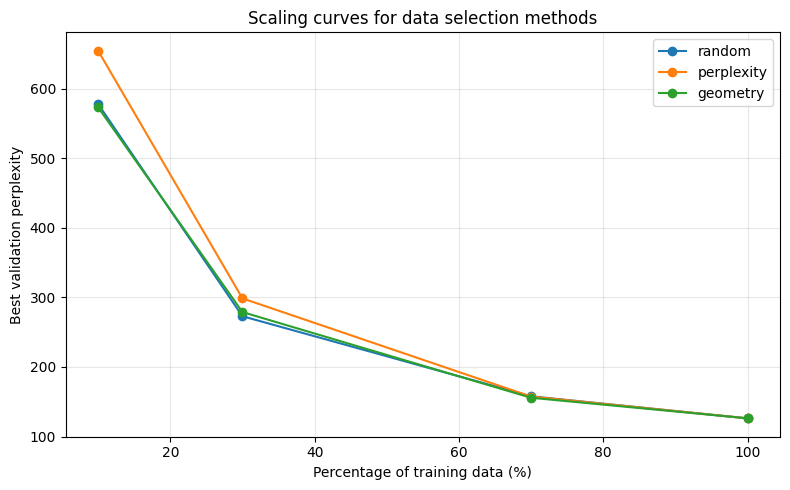

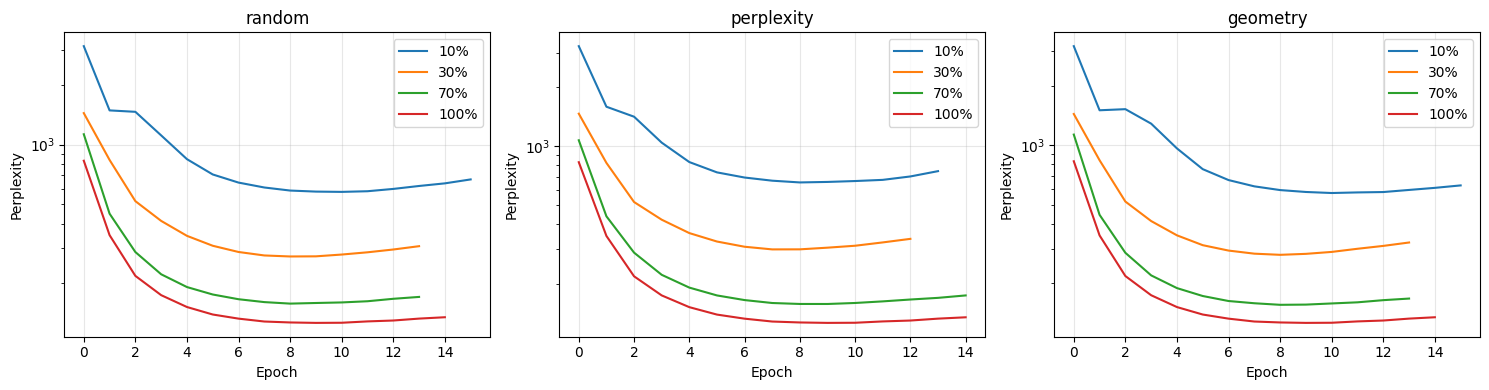

method,geometry,perplexity,random
percent,,,
10,573.141720,654.539206,577.921270
30,278.915952,298.603546,272.937568
70,155.776856,157.492061,157.863329
100,126.193243,126.193243,126.193243


In [ ]:
def load_run_history_by_name(run_name):
    run_dir = exp_dir / run_name
    metrics_path = run_dir / "metrics.csv"
    status_path = run_dir / "status.json"
    ckpt_path = run_dir / "best.pt"

    if not metrics_path.exists():
        return None

    hist = pd.read_csv(metrics_path)
    if len(hist) == 0:
        return None

    status = load_status(status_path) if status_path.exists() else None
    return {
        "exp_name": run_name,
        "metrics_path": str(metrics_path),
        "ckpt_path": str(ckpt_path),
        "history": hist,
        "best_val_ppl": float(hist["val_ppl"].min()),
        "status": status,
        "completed": bool(status is not None and status.get("state") == "completed"),
    }

def recover_all_runs_from_disk():
    recovered = {}
    full = load_run_history_by_name("full_100")
    if full is not None:
        recovered["full"] = full

    for method in methods:
        for frac in cfg.fractions:
            run_name = f"{method}_{int(frac * 100)}"
            run = load_run_history_by_name(run_name)
            if run is not None:
                recovered[run_name] = run
    return recovered

if "all_runs" not in globals() or not isinstance(all_runs, dict) or len(all_runs) == 0:
    all_runs = recover_all_runs_from_disk()
else:
    recovered = recover_all_runs_from_disk()
    for key, value in recovered.items():
        if key not in all_runs:
            all_runs[key] = value

print("available runs:", sorted(all_runs.keys()))

def best_val_ppl_from_run(run):
    hist = run["history"]
    return float(hist["val_ppl"].min())

required_run_keys = ["full"] + [
    f"{method}_{int(frac * 100)}"
    for method in methods
    for frac in cfg.fractions
]
missing_runs = [k for k in required_run_keys if k not in all_runs]
completed_runs = [k for k, v in all_runs.items() if v.get("completed")]
partial_runs = [k for k, v in all_runs.items() if not v.get("completed")]

print("completed runs:", completed_runs)
print("partial runs:", partial_runs)
print("missing runs:", missing_runs)

scaling_rows = []
for method in methods:
    for frac in cfg.fractions:
        run_name = f"{method}_{int(frac * 100)}"
        if run_name not in all_runs:
            continue
        scaling_rows.append(
            {
                "method": method,
                "fraction": frac,
                "percent": int(frac * 100),
                "best_val_ppl": best_val_ppl_from_run(all_runs[run_name]),
                "completed": all_runs[run_name].get("completed", False),
            }
        )

full_best = best_val_ppl_from_run(all_runs["full"]) if "full" in all_runs else None
if full_best is not None:
    for method in methods:
        scaling_rows.append(
            {
                "method": method,
                "fraction": 1.0,
                "percent": 100,
                "best_val_ppl": full_best,
                "completed": all_runs["full"].get("completed", False),
            }
        )

scaling_df = pd.DataFrame(scaling_rows).sort_values(["method", "fraction"]).reset_index(drop=True)
display(scaling_df)

if len(scaling_df):
    plt.figure(figsize=(8, 5))
    for method in methods:
        part = scaling_df[scaling_df["method"] == method].sort_values("fraction")
        if len(part) == 0:
            continue
        plt.plot(part["percent"], part["best_val_ppl"], marker="o", label=method)
    plt.xlabel("Percentage of training data (%)")
    plt.ylabel("Best validation perplexity")
    plt.title("Scaling curves for data selection methods")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / "scaling_curves.png", dpi=160, bbox_inches="tight")
    plt.show()

available_methods = [m for m in methods if any(f"{m}_{int(frac * 100)}" in all_runs for frac in cfg.fractions)]
if available_methods:
    fig, axes = plt.subplots(1, len(available_methods), figsize=(5 * len(available_methods), 4), sharey=False)
    if len(available_methods) == 1:
        axes = [axes]

    for ax, method in zip(axes, available_methods):
        for frac in cfg.fractions:
            run_name = f"{method}_{int(frac * 100)}"
            if run_name not in all_runs:
                continue
            hist = all_runs[run_name]["history"]
            ax.plot(hist["epoch"], hist["val_ppl"], label=f"{int(frac * 100)}%")
        if "full" in all_runs:
            full_hist = all_runs["full"]["history"]
            ax.plot(full_hist["epoch"], full_hist["val_ppl"], label="100%")
        ax.set_title(method)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Perplexity")
        ax.set_yscale("log")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.savefig(out_dir / "training_curves.png", dpi=160, bbox_inches="tight")
    plt.show()

if len(scaling_df):
    best_summary_df = scaling_df.pivot(index="percent", columns="method", values="best_val_ppl").sort_index()
    display(best_summary_df)
else:
    best_summary_df = pd.DataFrame()

In [ ]:
if len(scaling_df):
    scaling_df.to_csv(out_dir / "scaling_results.csv", index=False)

summary = {
    "cfg": asdict(cfg),
    "device": device,
    "train_stats": train_stats,
    "val_stats": val_stats,
    "available_runs": sorted(all_runs.keys()),
    "completed_runs": completed_runs,
    "partial_runs": partial_runs,
    "missing_runs": missing_runs,
    "full_best_val_ppl": float(full_best) if full_best is not None else None,
    "best_by_method": {},
}

if len(scaling_df):
    for method in methods:
        method_rows = scaling_df[scaling_df["method"] == method]
        summary["best_by_method"][method] = {
            f"{int(row['percent'])}%": float(row["best_val_ppl"])
            for _, row in method_rows.sort_values("fraction").iterrows()
        }

with open(out_dir / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("saved to", out_dir)
print("main files:")
for p in [
    out_dir / "cfg.json",
    out_dir / "data_stats.json",
    out_dir / "selection_scores.csv",
    out_dir / "summary.json",
    out_dir / "scaling_results.csv",
    out_dir / "scaling_curves.png",
    out_dir / "training_curves.png",
]:
    print("-", p, "| exists:", Path(p).exists())

print()
print("summary:")
print(json.dumps(summary, ensure_ascii=False, indent=2))

saved to /content/drive/MyDrive/geom_distill_outputs
main files:
- /content/drive/MyDrive/geom_distill_outputs/cfg.json | exists: True
- /content/drive/MyDrive/geom_distill_outputs/data_stats.json | exists: True
- /content/drive/MyDrive/geom_distill_outputs/selection_scores.csv | exists: True
- /content/drive/MyDrive/geom_distill_outputs/summary.json | exists: True
- /content/drive/MyDrive/geom_distill_outputs/scaling_results.csv | exists: True
- /content/drive/MyDrive/geom_distill_outputs/scaling_curves.png | exists: True
- /content/drive/MyDrive/geom_distill_outputs/training_curves.png | exists: True

summary:
{
  "cfg": {
    "dataset_name": "wikitext",
    "dataset_config": "wikitext-103-raw-v1",
    "use_streaming": true,
    "max_train_chunks": 6000,
    "max_val_chunks": 1200,
    "stream_progress_every": 100000,
    "vocab_size": 8192,
    "block_size": 128,
    "stride": 64,
    "batch_size": 48,
    "eval_batch_size": 64,
    "num_workers": 0,
    "d_model": 320,
    "nhead":